# 04c — model_enrollment

**Task:** Predict total enrollment for a course in a given term (regressor)  
**Input:** `data/processed/enrollment_train.csv`, `enrollment_test.csv`  
**Train target:** `log_enrolled` (log-transformed for training)  
**Evaluate in:** real students (inverse transform with `np.expm1`)  

**Models tested:**
1. Baseline — always predict mean training enrollment
2. Linear Regression
3. Ridge Regression
4. Random Forest
5. Gradient Boosting

**Selection metric:** MAE in real students (lower = better), RMSE as tiebreaker

In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

DATA_PATH   = Path('../data/processed')
MODELS_PATH = Path('../models')
FIG_PATH    = Path('../figures/04c_model_enrollment')
MODELS_PATH.mkdir(exist_ok=True)
FIG_PATH.mkdir(parents=True, exist_ok=True)

FEATURES = [
    'ml_course_id', 'dept_code_enc', 'degree_level_enc', 'course_level', 'units',
    'term_order', 'is_covid_affected',
    'hist_avg_capacity_per_offering', 'hist_avg_capacity_this_semester',
    'hist_avg_enrollment_per_offering', 'hist_avg_enrollment_this_semester',
    'same_semester_enrollment_ratio', 'previous_same_semester_enrollment',
    'previous_term_enrollment', 'enrollment_trend',
    'hist_n_offerings', 'hist_avg_sections_per_offering',
    'high_fill_rate_frequency', 'prereq_count', 'course_age_terms',
]
LOG_TARGET  = 'log_enrolled'
REAL_TARGET = 'total_enrolled'

print('ready')

ready


---
## 1. Load data

In [2]:
train = pd.read_csv(DATA_PATH / 'enrollment_train.csv')
test  = pd.read_csv(DATA_PATH / 'enrollment_test.csv')

X_train  = train[FEATURES];   y_train_log  = train[LOG_TARGET];  y_train_real = train[REAL_TARGET]
X_test   = test[FEATURES];    y_test_log   = test[LOG_TARGET];   y_test_real  = test[REAL_TARGET]

scaler    = StandardScaler()
X_train_s = pd.DataFrame(scaler.fit_transform(X_train), columns=FEATURES)
X_test_s  = pd.DataFrame(scaler.transform(X_test),      columns=FEATURES)

print(f'X_train: {X_train.shape}  mean enrollment: {y_train_real.mean():.1f} students')
print(f'X_test:  {X_test.shape}   mean enrollment: {y_test_real.mean():.1f} students')
print(f'features: {len(FEATURES)}')

X_train: (22854, 20)  mean enrollment: 50.4 students
X_test:  (1522, 20)   mean enrollment: 49.4 students
features: 20


---
## 2. Helper functions

In [3]:
results = []

def evaluate_regressor(name, y_true_real, y_pred_log):
    y_pred_real = np.expm1(y_pred_log)
    mae  = mean_absolute_error(y_true_real, y_pred_real)
    rmse = np.sqrt(mean_squared_error(y_true_real, y_pred_real))
    r2   = r2_score(y_true_real, y_pred_real)
    return {'model': name, 'mae': round(mae, 2), 'rmse': round(rmse, 2), 'r2': round(r2, 4)}

def plot_pred_vs_actual(ax, y_true_real, y_pred_log, title, color):
    y_pred_real = np.expm1(y_pred_log)
    ax.scatter(y_true_real, y_pred_real, alpha=0.3, s=8, color=color)
    lim = max(y_true_real.max(), y_pred_real.max())
    ax.plot([0, lim], [0, lim], 'k--', lw=1, label='perfect')
    mae = mean_absolute_error(y_true_real, y_pred_real)
    ax.set_xlabel('Actual students')
    ax.set_ylabel('Predicted students')
    ax.set_title(f'{title}\nMAE={mae:.1f} students')

print('helpers defined')

helpers defined


---
## 3. Baseline

In [4]:
mean_log   = y_train_log.mean()
y_base_log = np.full(len(y_test_log), mean_log)

base_metrics = evaluate_regressor('Baseline', y_test_real, y_base_log)
results.append(base_metrics)

print(f'Baseline always predicts: {np.expm1(mean_log):.1f} students')
print(f'Baseline MAE:  {base_metrics["mae"]:.2f} students')
print(f'Baseline RMSE: {base_metrics["rmse"]:.2f} students')
print(f'Baseline R²:   {base_metrics["r2"]}')
print('Every model must beat this MAE.')

Baseline always predicts: 22.3 students
Baseline MAE:  39.89 students
Baseline RMSE: 83.22 students
Baseline R²:   -0.1193
Every model must beat this MAE.


---
## 4. Linear Regression

{'model': 'Linear Regression', 'mae': np.float64(48.85), 'rmse': np.float64(401.83), 'r2': -25.0963}


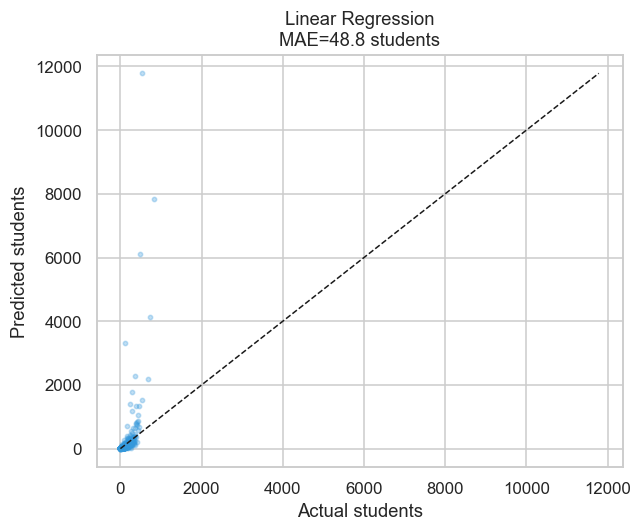

In [5]:
lr = LinearRegression()
lr.fit(X_train_s, y_train_log)
y_lr = lr.predict(X_test_s)

lr_metrics = evaluate_regressor('Linear Regression', y_test_real, y_lr)
results.append(lr_metrics)
print(lr_metrics)

fig, ax = plt.subplots(figsize=(6, 5))
plot_pred_vs_actual(ax, y_test_real, y_lr, 'Linear Regression', '#3498db')
plt.tight_layout()
plt.savefig(FIG_PATH / 'lr.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Ridge Regression

{'model': 'Ridge Regression', 'mae': np.float64(51.5), 'rmse': np.float64(454.8), 'r2': -32.4307}
Best alpha: 500.0


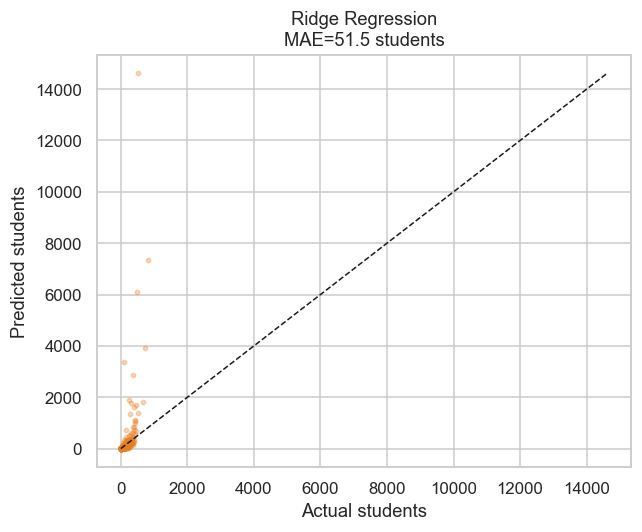

In [6]:
ridge = RidgeCV(alphas=[0.1, 1.0, 10.0, 100.0, 500.0], cv=5)
ridge.fit(X_train_s, y_train_log)
y_ridge = ridge.predict(X_test_s)

ridge_metrics = evaluate_regressor('Ridge Regression', y_test_real, y_ridge)
results.append(ridge_metrics)
print(ridge_metrics)
print(f'Best alpha: {ridge.alpha_}')

fig, ax = plt.subplots(figsize=(6, 5))
plot_pred_vs_actual(ax, y_test_real, y_ridge, 'Ridge Regression', '#e67e22')
plt.tight_layout()
plt.savefig(FIG_PATH / 'ridge.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Random Forest

{'model': 'Random Forest', 'mae': np.float64(11.85), 'rmse': np.float64(24.13), 'r2': 0.9059}


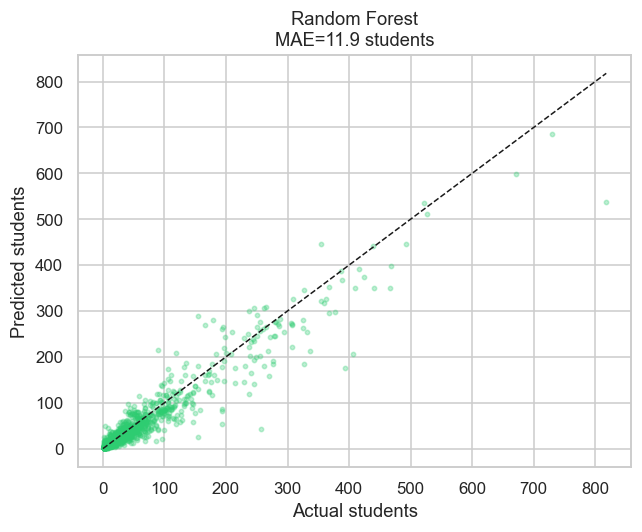

In [7]:
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train_log)
y_rf = rf.predict(X_test)

rf_metrics = evaluate_regressor('Random Forest', y_test_real, y_rf)
results.append(rf_metrics)
print(rf_metrics)

fig, ax = plt.subplots(figsize=(6, 5))
plot_pred_vs_actual(ax, y_test_real, y_rf, 'Random Forest', '#2ecc71')
plt.tight_layout()
plt.savefig(FIG_PATH / 'rf.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Gradient Boosting

{'model': 'Gradient Boosting', 'mae': np.float64(12.32), 'rmse': np.float64(25.8), 'r2': 0.8924}


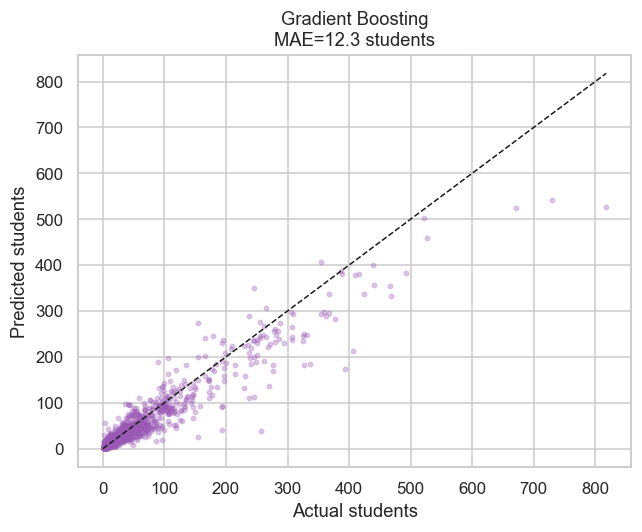

In [8]:
gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42)
gb.fit(X_train, y_train_log)
y_gb = gb.predict(X_test)

gb_metrics = evaluate_regressor('Gradient Boosting', y_test_real, y_gb)
results.append(gb_metrics)
print(gb_metrics)

fig, ax = plt.subplots(figsize=(6, 5))
plot_pred_vs_actual(ax, y_test_real, y_gb, 'Gradient Boosting', '#9b59b6')
plt.tight_layout()
plt.savefig(FIG_PATH / 'gb.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Comparison

=== ALL MODELS (evaluated in real students) ===
                     mae    rmse       r2
model                                    
Baseline           39.89   83.22  -0.1193
Linear Regression  48.85  401.83 -25.0963
Ridge Regression   51.50  454.80 -32.4307
Random Forest      11.85   24.13   0.9059
Gradient Boosting  12.32   25.80   0.8924


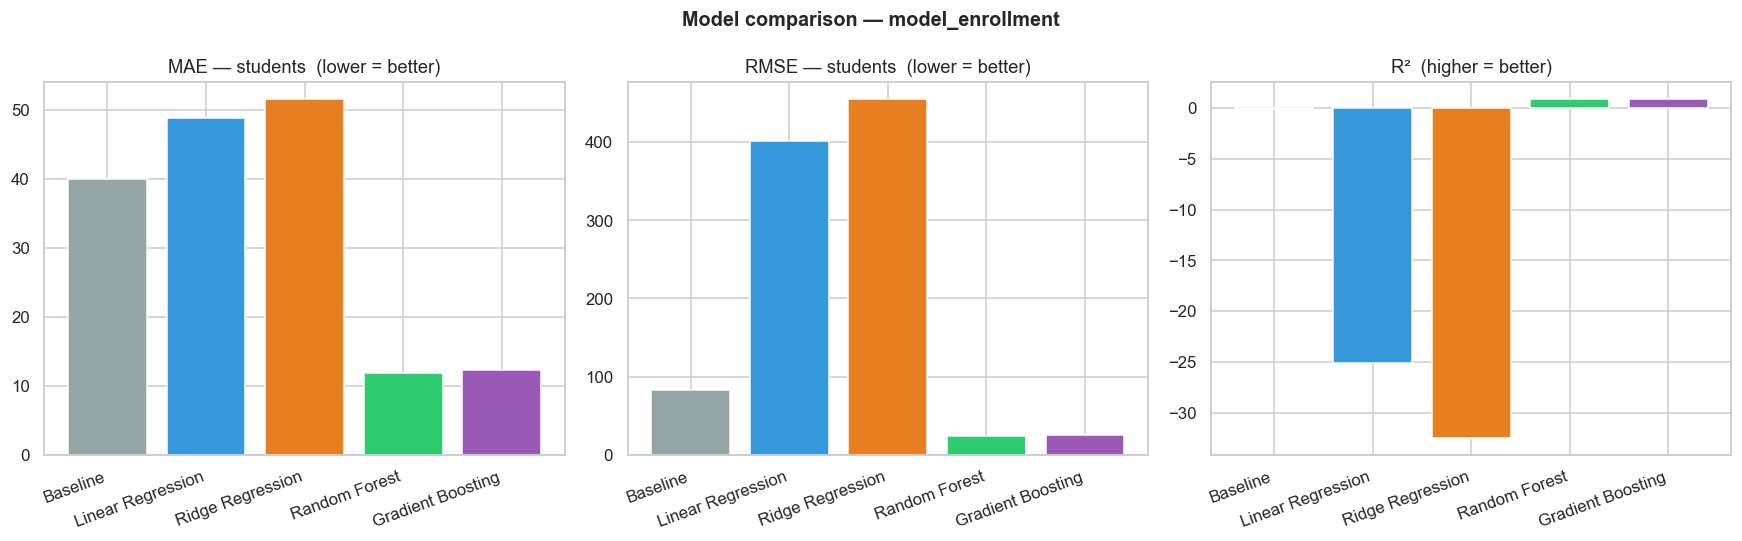

In [9]:
results_df = pd.DataFrame(results).set_index('model')
print('=== ALL MODELS (evaluated in real students) ===')
print(results_df.to_string())
results_df.to_csv(DATA_PATH / '04c_results.csv')

colors = ['#95a5a6','#3498db','#e67e22','#2ecc71','#9b59b6']
models = results_df.index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Model comparison — model_enrollment', fontsize=13, fontweight='bold')
for ax, metric, label in [
    (axes[0], 'mae',  'MAE — students  (lower = better)'),
    (axes[1], 'rmse', 'RMSE — students  (lower = better)'),
    (axes[2], 'r2',   'R²  (higher = better)'),
]:
    ax.bar(models, results_df[metric], color=colors, edgecolor='white')
    ax.set_title(label)
    plt.setp(ax.get_xticklabels(), rotation=20, ha='right')
plt.tight_layout()
plt.savefig(FIG_PATH / 'comparison.png', dpi=150, bbox_inches='tight')
plt.show()

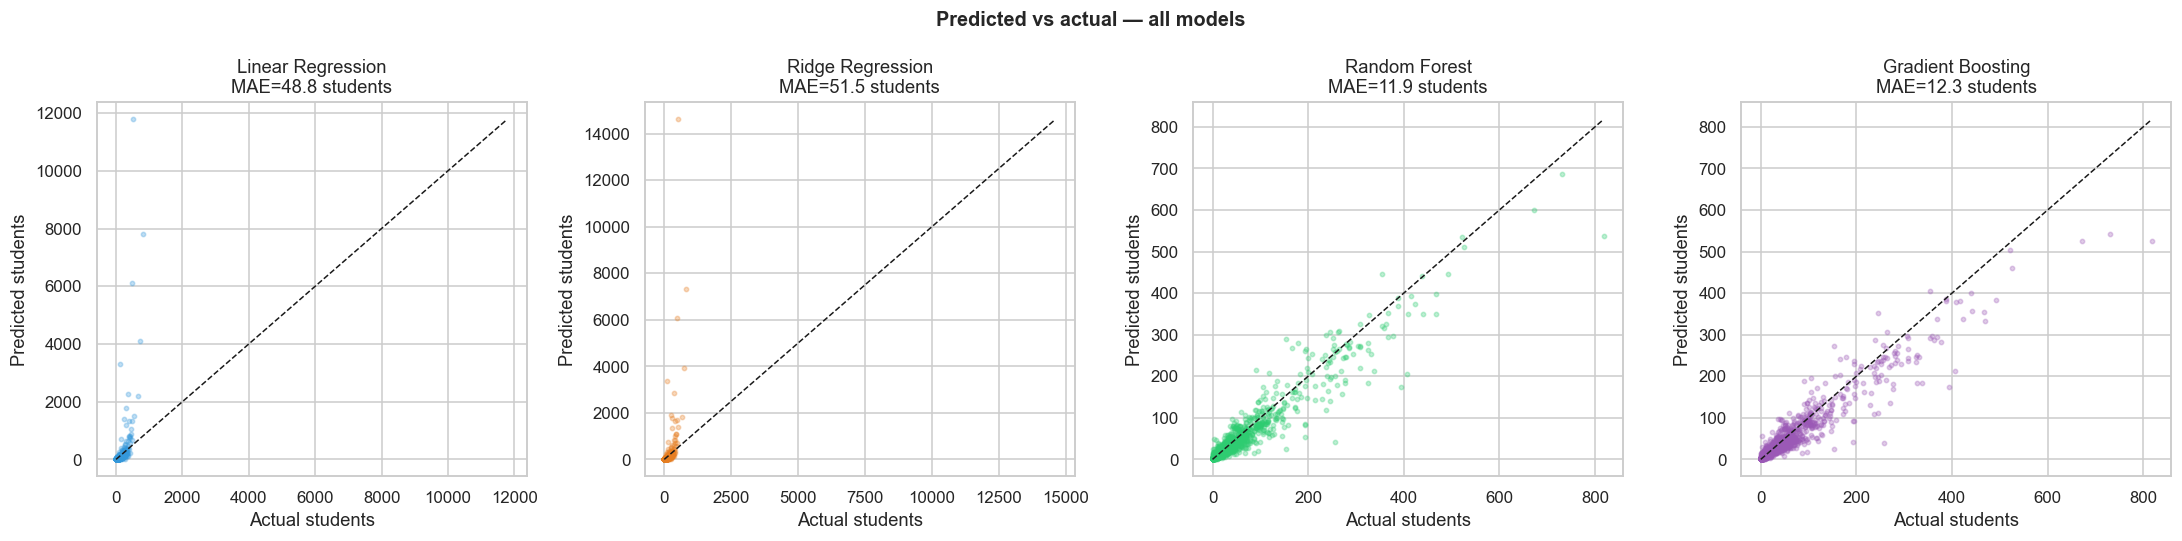

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Predicted vs actual — all models', fontsize=13, fontweight='bold')
for ax, (name, y_pred, color) in zip(axes, [
    ('Linear Regression', y_lr,    '#3498db'),
    ('Ridge Regression',  y_ridge, '#e67e22'),
    ('Random Forest',     y_rf,    '#2ecc71'),
    ('Gradient Boosting', y_gb,    '#9b59b6'),
]):
    plot_pred_vs_actual(ax, y_test_real, y_pred, name, color)
plt.tight_layout()
plt.savefig(FIG_PATH / 'pred_vs_actual_all.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Winner — feature importance + residuals + save

In [11]:
model_map = {
    'Linear Regression': (lr,    X_test_s, y_lr),
    'Ridge Regression':  (ridge, X_test_s, y_ridge),
    'Random Forest':     (rf,    X_test,   y_rf),
    'Gradient Boosting': (gb,    X_test,   y_gb),
}

non_base = results_df.drop('Baseline')
min_mae  = non_base['mae'].min()
tied     = non_base[non_base['mae'] == min_mae]
best_row = tied['rmse'].idxmin()

best_model, best_X_test, best_y_pred_log = model_map[best_row]
best_y_pred_real = np.expm1(best_y_pred_log)

print(f'Winner: {best_row}')
print(f'  MAE:  {results_df.loc[best_row, "mae"]} students')
print(f'  RMSE: {results_df.loc[best_row, "rmse"]} students')
print(f'  R²:   {results_df.loc[best_row, "r2"]}')

Winner: Random Forest
  MAE:  11.85 students
  RMSE: 24.13 students
  R²:   0.9059


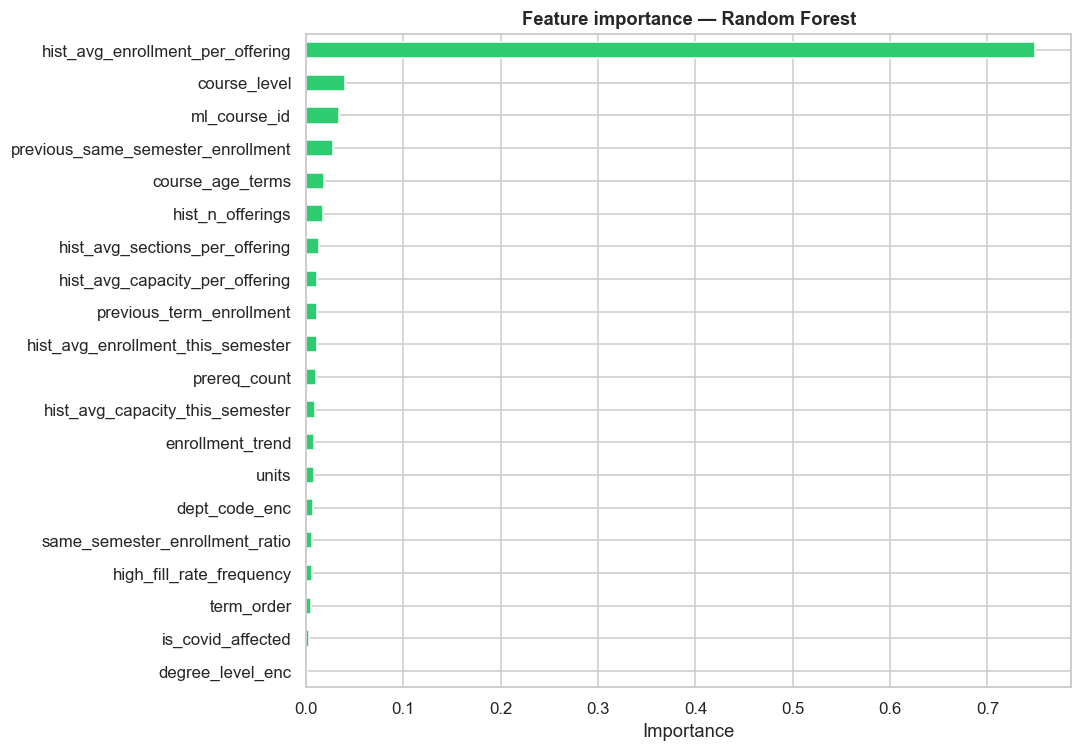

In [12]:
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=FEATURES).sort_values()
    fig, ax = plt.subplots(figsize=(10, 7))
    importances.plot(kind='barh', ax=ax, color='#2ecc71', edgecolor='white')
    ax.set_title(f'Feature importance — {best_row}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.savefig(FIG_PATH / 'winner_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print(f'{best_row} has no feature_importances_')

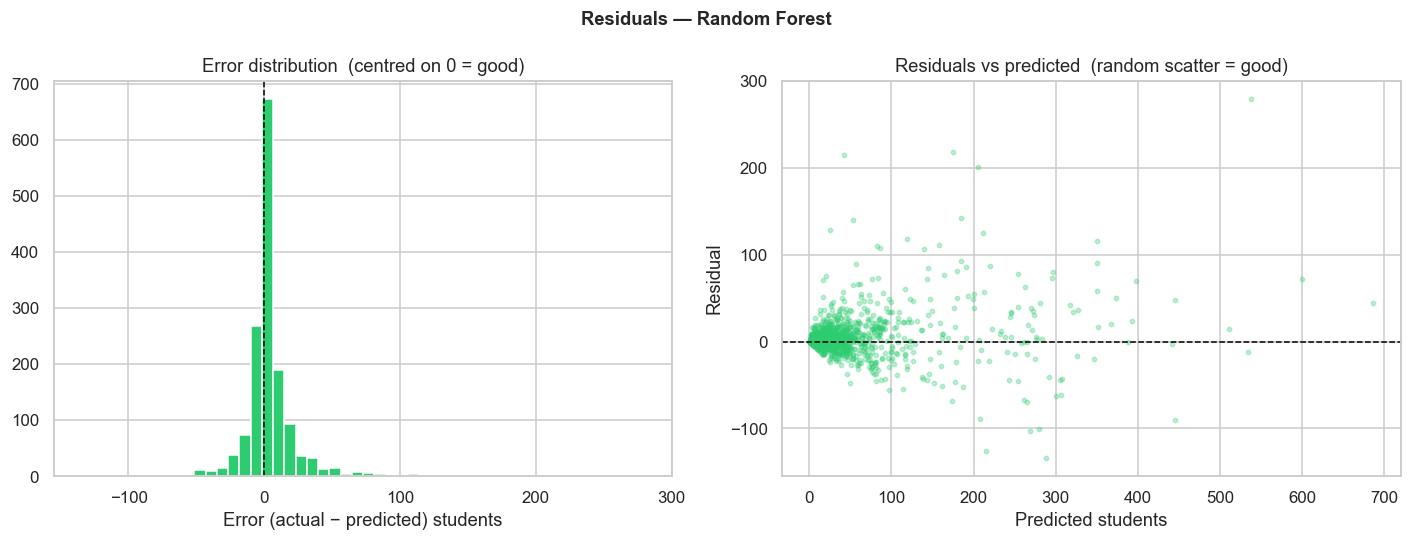

Mean error:   4.28  (should be ~0)
Std of error: 23.74 students
Max overpredict:  -134.4 students
Max underpredict: 279.9 students


In [13]:
residuals = y_test_real.values - best_y_pred_real

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'Residuals — {best_row}', fontsize=12, fontweight='bold')

axes[0].hist(residuals, bins=50, color='#2ecc71', edgecolor='white')
axes[0].axvline(0, color='black', linestyle='--', lw=1)
axes[0].set_xlabel('Error (actual − predicted) students')
axes[0].set_title('Error distribution  (centred on 0 = good)')

axes[1].scatter(best_y_pred_real, residuals, alpha=0.3, s=8, color='#2ecc71')
axes[1].axhline(0, color='black', linestyle='--', lw=1)
axes[1].set_xlabel('Predicted students')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residuals vs predicted  (random scatter = good)')

plt.tight_layout()
plt.savefig(FIG_PATH / 'winner_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Mean error:   {residuals.mean():.2f}  (should be ~0)')
print(f'Std of error: {residuals.std():.2f} students')
print(f'Max overpredict:  {residuals.min():.1f} students')
print(f'Max underpredict: {residuals.max():.1f} students')

In [14]:
joblib.dump(best_model, MODELS_PATH / 'model_enrollment.pkl')
joblib.dump(scaler,     MODELS_PATH / 'scaler_enrollment.pkl')
print(f'saved: model_enrollment.pkl  ({best_row})')
print(f'saved: scaler_enrollment.pkl')

saved: model_enrollment.pkl  (Random Forest)
saved: scaler_enrollment.pkl
